In [ ]:
!pip install -q transformers accelerate torch datasets scikit-learn

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.cluster import KMeans
import math

model_id = "gpt2"
device = "cuda"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
model.eval()

print("Loaded model:", model_id)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded model: gpt2


In [ ]:
@torch.no_grad()
def perplexity(model, text: str):
    enc = tokenizer(text, return_tensors="pt").to(device)
    out = model(**enc, labels=enc["input_ids"])
    loss = out.loss.item()
    return math.exp(loss)

def uniform_int8_quantize(weights: torch.Tensor):
    w = weights.detach().cpu()
    max_val = w.abs().max()
    qmax = 127  # signed int8 range [-127, 127]

    scale = max_val / qmax if max_val > 0 else 1.0
    q = torch.clamp(torch.round(w / scale), -qmax, qmax).to(torch.int8)
    w_hat = (q.to(torch.float32) * scale)

    mse = torch.mean((w - w_hat)**2).item()
    return q, w_hat, scale, mse

def kmeans_quantize(weights: torch.Tensor, n_bits=8, max_samples=50000):
    w = weights.detach().cpu().reshape(-1, 1)

    K = 2 ** n_bits
    if w.shape[0] > max_samples:
        idx = torch.randperm(w.shape[0])[:max_samples]
        w_sample = w[idx].numpy()
    else:
        w_sample = w.numpy()

    kmeans = KMeans(n_clusters=K, n_init=5, random_state=0)
    kmeans.fit(w_sample)

    centers = torch.from_numpy(kmeans.cluster_centers_.squeeze()).float()
    labels = kmeans.predict(w.numpy())
    labels = torch.from_numpy(labels).long()

    w_hat = centers[labels].reshape(weights.shape)
    mse = torch.mean((weights.cpu() - w_hat)**2).item()
    return centers, labels, w_hat, mse


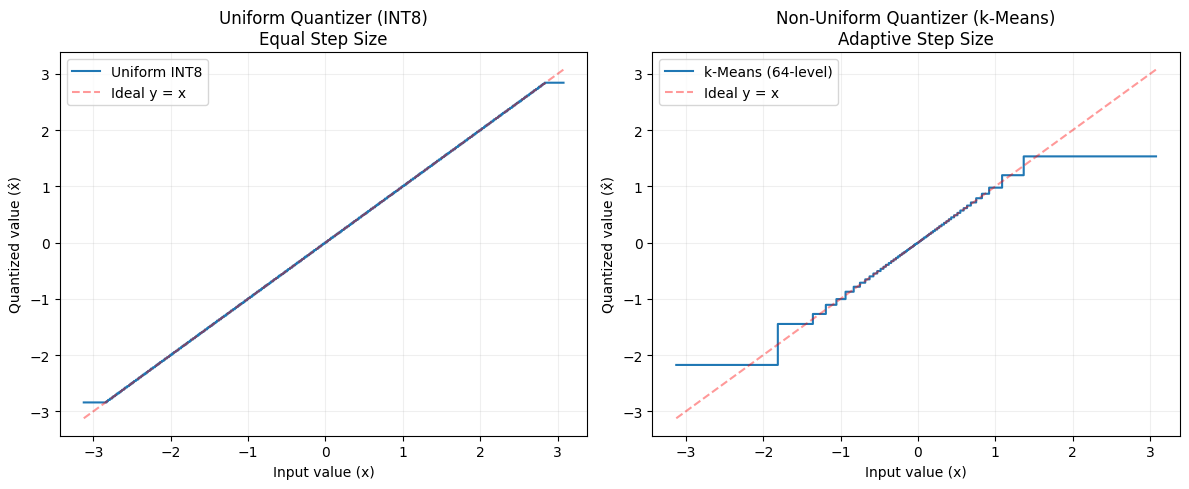

In [ ]:
# @title
import matplotlib.pyplot as plt

# ---- 1. Prepare a 1D range to visualize the quantizers on ----

# Use the same range as your layer weights to keep it realistic
w_min = weights.detach().cpu().min().item()
w_max = weights.detach().cpu().max().item()

# Slight padding so endpoints are visible
pad = 0.05 * (w_max - w_min)
x_vals = torch.linspace(w_min - pad, w_max + pad, steps=1000)

# ---- 2. Define scalar versions of the two quantizers ----

qmax = 127  # signed int8 range

def uniform_quantizer_scalar(x, scale):
    # x: 1D tensor
    q = torch.clamp(torch.round(x / scale), -qmax, qmax)
    x_hat = q * scale
    return x_hat

# For k-means, we use the learned centers as a codebook
# Make sure centers are sorted so the staircase looks nice
centers_sorted, _ = torch.sort(centers_km)  # centers_km from kmeans_quantize earlier

def kmeans_quantizer_scalar(x, centers):
    # x: 1D tensor, centers: 1D tensor of codebook values
    x_expanded = x.view(-1, 1)                      # [N, 1]
    centers_expanded = centers.view(1, -1)          # [1, K]
    # Compute distances and pick nearest center
    dists = torch.abs(x_expanded - centers_expanded)
    nearest_idx = torch.argmin(dists, dim=1)        # [N]
    x_hat = centers[nearest_idx]
    return x_hat

# ---- 3. Apply both quantizers on the same 1D grid ----

x_uni = uniform_quantizer_scalar(x_vals, scale_uni)          # scale_uni from uniform_int8_quantize
x_km  = kmeans_quantizer_scalar(x_vals, centers_sorted)

# Convert to numpy for plotting
x_np      = x_vals.numpy()
x_uni_np  = x_uni.numpy()
x_km_np   = x_km.numpy()

# ---- 4. Plot staircase functions ----

plt.figure(figsize=(12, 5))

# Uniform
plt.subplot(1, 2, 1)
plt.step(x_np, x_uni_np, where="mid", label="Uniform INT8", linewidth=1.5)
plt.plot(x_np, x_np, "r--", alpha=0.4, label="Ideal y = x")
plt.title("Uniform Quantizer (INT8)\nEqual Step Size")
plt.xlabel("Input value (x)")
plt.ylabel("Quantized value (x̂)")
plt.legend()
plt.grid(True, alpha=0.2)

# k-Means Non-Uniform
plt.subplot(1, 2, 2)
plt.step(x_np, x_km_np, where="mid", label="k-Means (64-level)", linewidth=1.5)
plt.plot(x_np, x_np, "r--", alpha=0.4, label="Ideal y = x")
plt.title("Non-Uniform Quantizer (k-Means)\nAdaptive Step Size")
plt.xlabel("Input value (x)")
plt.ylabel("Quantized value (x̂)")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [ ]:
# Take the first attention projection layer
layer = model.transformer.h[0].attn.c_attn
weights = layer.weight.data

q_uni, w_uni, scale_uni, mse_uni = uniform_int8_quantize(weights)
centers_km, labels_km, w_km, mse_km = kmeans_quantize(weights, n_bits=6)  # 64-level non-uniform

print(f"Uniform INT8 MSE:     {mse_uni:.6e}")
print(f"k-Means (64-level) MSE: {mse_km:.6e}")


Uniform INT8 MSE:     4.172964e-05
k-Means (64-level) MSE: 5.712012e-05


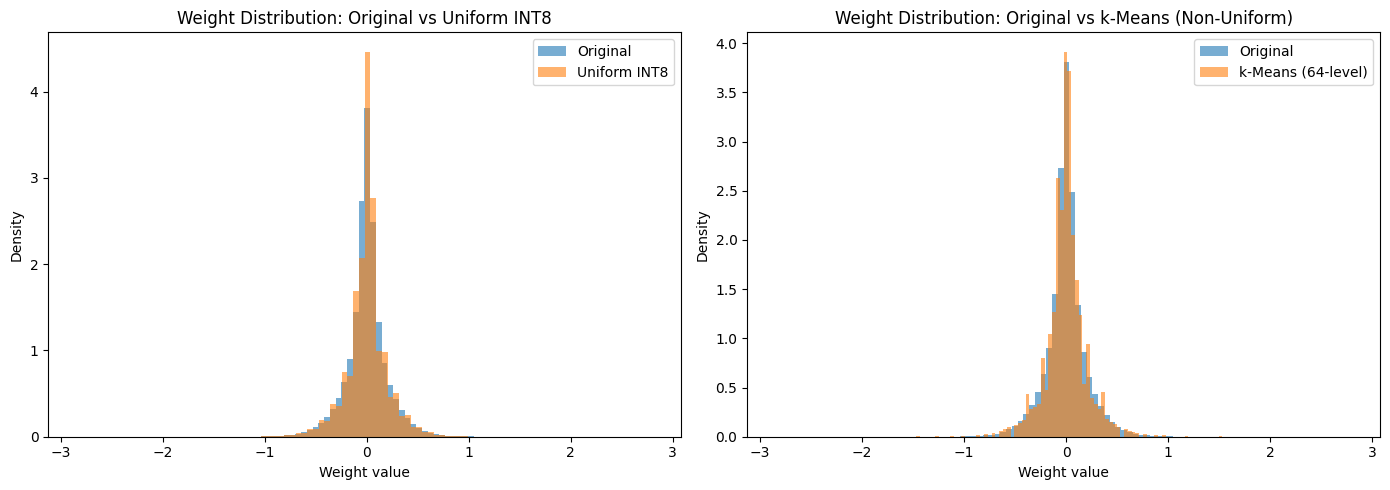

In [ ]:
# @title
import matplotlib.pyplot as plt

# Flatten everything for visualization
w_flat = weights.detach().cpu().view(-1)
w_uni_flat = w_uni.view(-1)
w_km_flat = w_km.view(-1)

plt.figure(figsize=(14, 5))

# Original vs Uniform
plt.subplot(1, 2, 1)
plt.hist(w_flat.numpy(), bins=100, alpha=0.6, label="Original", density=True)
plt.hist(w_uni_flat.numpy(), bins=100, alpha=0.6, label="Uniform INT8", density=True)
plt.title("Weight Distribution: Original vs Uniform INT8")
plt.xlabel("Weight value")
plt.ylabel("Density")
plt.legend()

# Original vs k-Means
plt.subplot(1, 2, 2)
plt.hist(w_flat.numpy(), bins=100, alpha=0.6, label="Original", density=True)
plt.hist(w_km_flat.numpy(), bins=100, alpha=0.6, label="k-Means (64-level)", density=True)
plt.title("Weight Distribution: Original vs k-Means (Non-Uniform)")
plt.xlabel("Weight value")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()
